# Supply Chain EDA — Exploratory Data Analysis
**Portfolio Project | Data Science**

This notebook explores three supply chain datasets:
- **shipments** — 3,000 individual shipments (Jan 2023 – Dec 2024)
- **carrier_scorecard** — monthly KPIs per carrier
- **lane_risk** — risk classification per shipping lane

The goal is to surface operational patterns that can drive smarter carrier selection,
cost control, and seasonal planning decisions.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})

DATA = Path("../data")

# ── Carrier colour palette ──────────────────────────────────────────────────
CARRIERS = ["FastFreight", "RelayEx", "PrimeHaul", "SwiftLog",
            "CargoLink", "NorthStar", "DirectMove"]

CARRIER_COLORS = {
    "FastFreight": "#2ecc71",   # green  — best performer
    "RelayEx":     "#3498db",
    "PrimeHaul":   "#5dade2",
    "SwiftLog":    "#f39c12",
    "CargoLink":   "#e67e22",
    "NorthStar":   "#e74c3c",
    "DirectMove":  "#c0392b",   # red    — worst performer
}

print("Libraries loaded.")


Libraries loaded.


---
## 1. Dataset Overview

Before any analysis, we check what we're working with: dimensions, column types,
and whether any data is missing. Clean, complete data underpins trustworthy insights.


In [2]:
shipments  = pd.read_csv(DATA / "shipments.csv",         parse_dates=["date"])
scorecard  = pd.read_csv(DATA / "carrier_scorecard.csv")
lane_risk  = pd.read_csv(DATA / "lane_risk.csv")

for name, df in [("shipments", shipments), ("carrier_scorecard", scorecard), ("lane_risk", lane_risk)]:
    print(f"{'='*55}")
    print(f"  {name}  — {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"{'='*55}")
    info = pd.DataFrame({
        "dtype":    df.dtypes.astype(str),
        "non_null": df.notnull().sum(),
        "missing":  df.isnull().sum(),
        "miss_%":   (df.isnull().mean() * 100).round(1),
        "sample":   df.iloc[0].astype(str),
    })
    print(info.to_string())
    print()


  shipments  — 3,000 rows x 18 columns
                             dtype  non_null  missing  miss_%               sample
shipment_id                    str      3000        0     0.0            SHP-01790
date                datetime64[us]      3000        0     0.0  2023-01-01 00:00:00
direction                      str      3000        0     0.0             outbound
carrier                        str      3000        0     0.0           DirectMove
origin                         str      3000        0     0.0          Atlanta, GA
destination                    str      3000        0     0.0      San Antonio, TX
lane_id                        str      3000        0     0.0                GA-TX
sku_category                   str      3000        0     0.0     Industrial Parts
weight_kg                  float64      3000        0     0.0                 63.3
quantity                     int64      3000        0     0.0                  223
promised_lead_days           int64      3000    

In [3]:
# Descriptive statistics for shipments numeric columns
shipments.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T.round(2)


,count,mean,min,5%,25%,50%,75%,95%,max,std
date,3000,2023-12-23 15:24:57.600000,2023-01-01 00:00:00,2023-01-31 00:00:00,2023-07-01 00:00:00,2023-12-20 00:00:00,2024-06-18 00:00:00,2024-11-20 00:00:00,2024-12-30 00:00:00,NaN
weight_kg,3000.0,126.1618,4.2,23.795,53.675,90.7,158.075,349.55,1375.3,117.742203
quantity,3000.0,67.751667,1.0,10.0,23.0,44.0,83.0,198.0,1022.0,78.822304
promised_lead_days,3000.0,5.560667,2.0,2.0,3.0,5.0,7.0,14.0,14.0,3.079959
actual_lead_days,3000.0,6.704667,1.0,2.0,4.0,6.0,9.0,14.0,21.0,3.564783
delay_days,3000.0,1.139567,-4.6,-1.4,-0.1,0.9,2.2,4.5,9.0,1.80354
is_delayed,3000.0,0.717667,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.45021
freight_cost_usd,3000.0,7.705693,3.06,4.019,5.1575,6.59,8.92,14.9025,52.71,4.182775
invoiced_cost_usd,3000.0,8.01043,2.96,4.1395,5.3775,6.83,9.24,15.8105,53.12,4.368799
cost_variance_usd,3000.0,0.304737,-2.56,-0.37,0.01,0.24,0.53,1.17,4.99,0.514283


---
## 2. Delay Analysis

**Delay days** = actual lead time minus promised lead time.
- Positive values mean the shipment arrived late.
- Negative values mean it arrived early.

We look at the overall distribution first, then slice by carrier, direction,
product category, and month to find where delays concentrate.


Late shipments  : 71.8%
Early shipments : 25.6%
On-time (=0)    : 2.6%


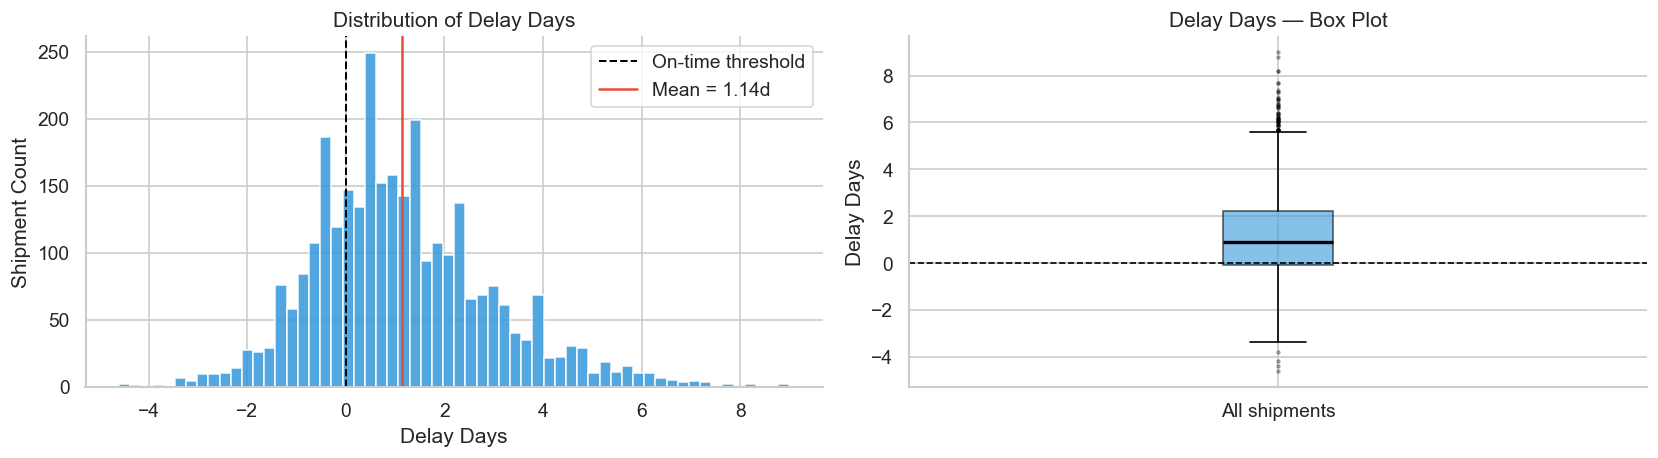

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
ax = axes[0]
ax.hist(shipments["delay_days"], bins=60, color="#3498db", edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", lw=1.2, ls="--", label="On-time threshold")
ax.axvline(shipments["delay_days"].mean(), color="#e74c3c", lw=1.5, ls="-",
           label=f"Mean = {shipments['delay_days'].mean():.2f}d")
ax.set_xlabel("Delay Days")
ax.set_ylabel("Shipment Count")
ax.set_title("Distribution of Delay Days")
ax.legend()

# Box plot
ax = axes[1]
ax.boxplot(shipments["delay_days"].dropna(), vert=True, patch_artist=True,
           boxprops=dict(facecolor="#3498db", alpha=0.6),
           medianprops=dict(color="black", lw=2),
           flierprops=dict(marker=".", markersize=3, alpha=0.4))
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_ylabel("Delay Days")
ax.set_title("Delay Days — Box Plot")
ax.set_xticks([1]); ax.set_xticklabels(["All shipments"])

pct_late  = (shipments["is_delayed"].mean() * 100)
pct_early = ((shipments["delay_days"] < 0).mean() * 100)
print(f"Late shipments  : {pct_late:.1f}%")
print(f"Early shipments : {pct_early:.1f}%")
print(f"On-time (=0)    : {100-pct_late-pct_early:.1f}%")

plt.tight_layout()
plt.savefig("../data/fig_delay_overview.png", bbox_inches="tight")
plt.show()


### 2a. Delay by Carrier

Does the choice of carrier significantly affect how often shipments are late?


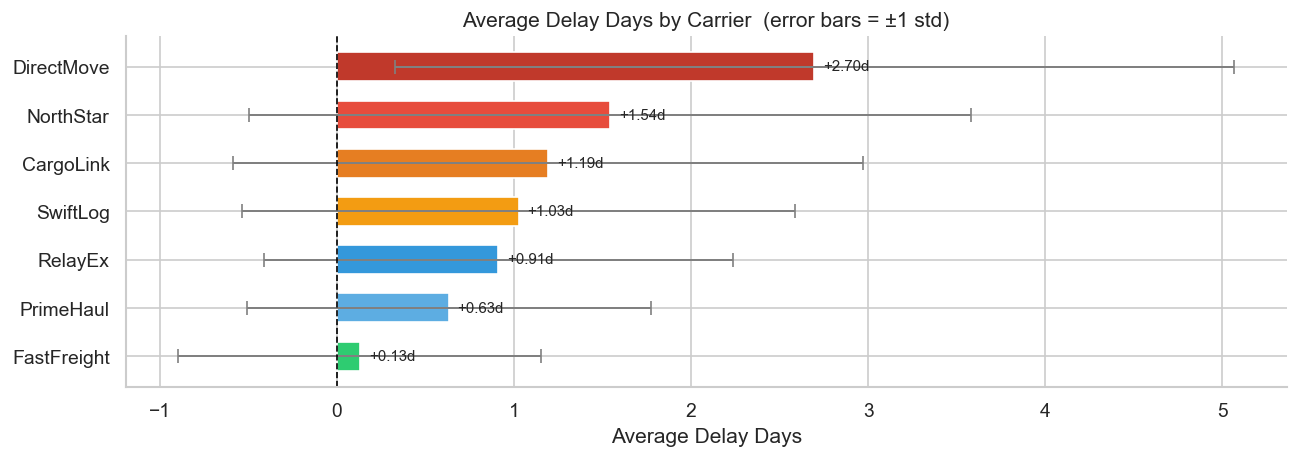

In [5]:
carrier_delay = (
    shipments.groupby("carrier")["delay_days"]
    .agg(["mean", "median", "std"])
    .rename(columns={"mean":"avg_delay","median":"med_delay","std":"std_delay"})
    .reindex(CARRIERS)
    .sort_values("avg_delay")
)

fig, ax = plt.subplots(figsize=(11, 4))
colors = [CARRIER_COLORS[c] for c in carrier_delay.index]
bars = ax.barh(carrier_delay.index, carrier_delay["avg_delay"], color=colors, edgecolor="white", height=0.6)
ax.errorbar(carrier_delay["avg_delay"], range(len(carrier_delay)),
            xerr=carrier_delay["std_delay"], fmt="none", color="grey", capsize=4, lw=1.2)
ax.axvline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Average Delay Days")
ax.set_title("Average Delay Days by Carrier  (error bars = ±1 std)")
for bar, val in zip(bars, carrier_delay["avg_delay"]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:+.2f}d", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../data/fig_delay_by_carrier.png", bbox_inches="tight")
plt.show()


### 2b. Delay by Direction — Inbound vs Outbound

Inbound shipments typically involve more handoffs (supplier pick-up, customs, receiving dock)
compared to outbound, which we control more directly.


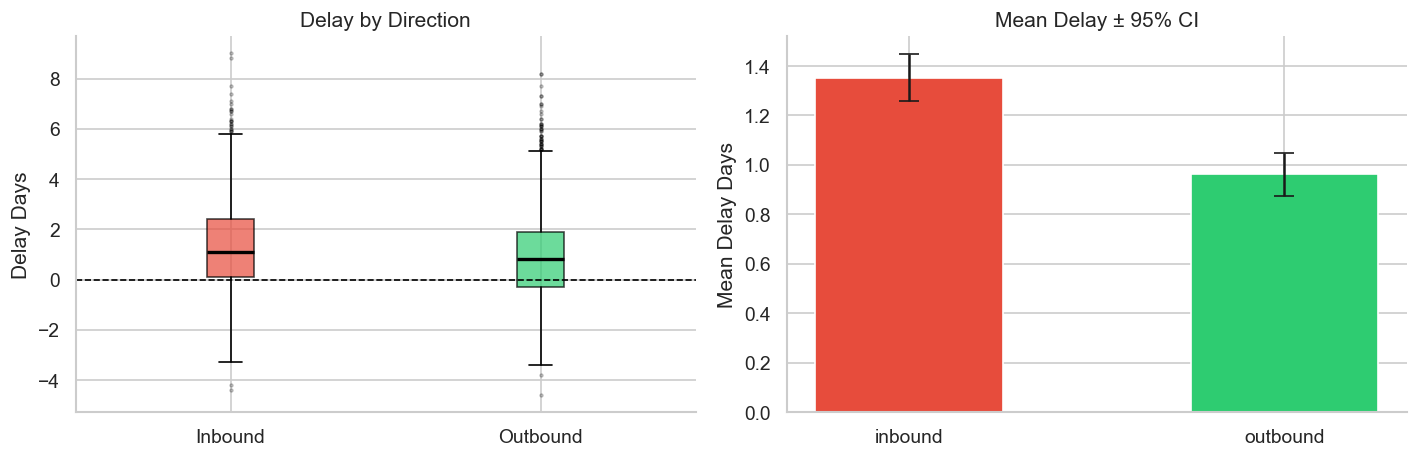

inbound     mean=+1.353d  95%CI=±0.094d
outbound    mean=+0.962d  95%CI=±0.088d


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot split by direction
dir_groups = [shipments.loc[shipments["direction"]==d, "delay_days"].dropna()
              for d in ["inbound", "outbound"]]
ax = axes[0]
bp = ax.boxplot(dir_groups, labels=["Inbound", "Outbound"], patch_artist=True,
                boxprops=dict(alpha=0.7),
                medianprops=dict(color="black", lw=2),
                flierprops=dict(marker=".", markersize=3, alpha=0.3))
for patch, color in zip(bp["boxes"], ["#e74c3c","#2ecc71"]):
    patch.set_facecolor(color)
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_ylabel("Delay Days"); ax.set_title("Delay by Direction")

# Mean + CI bar chart
dir_stats = shipments.groupby("direction")["delay_days"].agg(["mean","sem"]).reset_index()
ax = axes[1]
bar_colors = ["#e74c3c" if d=="inbound" else "#2ecc71" for d in dir_stats["direction"]]
ax.bar(dir_stats["direction"], dir_stats["mean"], color=bar_colors,
       yerr=dir_stats["sem"]*1.96, capsize=6, edgecolor="white", width=0.5)
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_ylabel("Mean Delay Days"); ax.set_title("Mean Delay ± 95% CI")

plt.tight_layout()
plt.savefig("../data/fig_delay_by_direction.png", bbox_inches="tight")
plt.show()

for _, row in dir_stats.iterrows():
    print(f"{row['direction']:10s}  mean={row['mean']:+.3f}d  95%CI=±{row['sem']*1.96:.3f}d")


### 2c. Delay by SKU Category

Some product categories may require special handling, increasing delay risk.


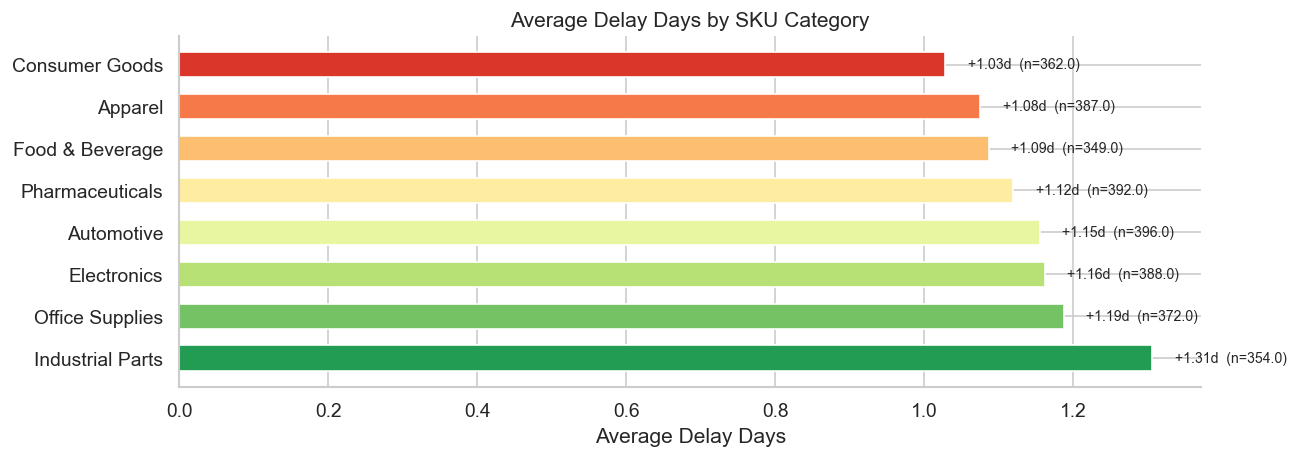

In [7]:
sku_delay = (
    shipments.groupby("sku_category")["delay_days"]
    .agg(["mean","median","count"])
    .sort_values("mean", ascending=False)
    .rename(columns={"mean":"avg_delay","median":"med_delay","count":"n"})
)

fig, ax = plt.subplots(figsize=(11, 4))
colors_sku = sns.color_palette("RdYlGn_r", len(sku_delay))
bars = ax.barh(sku_delay.index, sku_delay["avg_delay"], color=colors_sku, edgecolor="white", height=0.6)
ax.axvline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Average Delay Days")
ax.set_title("Average Delay Days by SKU Category")
for bar, (_, row) in zip(bars, sku_delay.iterrows()):
    ax.text(row["avg_delay"] + 0.03, bar.get_y() + bar.get_height()/2,
            f"{row['avg_delay']:+.2f}d  (n={row['n']})", va="center", fontsize=8.5)
plt.tight_layout()
plt.savefig("../data/fig_delay_by_sku.png", bbox_inches="tight")
plt.show()


### 2d. Seasonal Delay Pattern — Monthly Trend

Holiday season (Nov–Dec) is expected to drive significant delays due to carrier
capacity constraints and higher overall shipping volumes industry-wide.


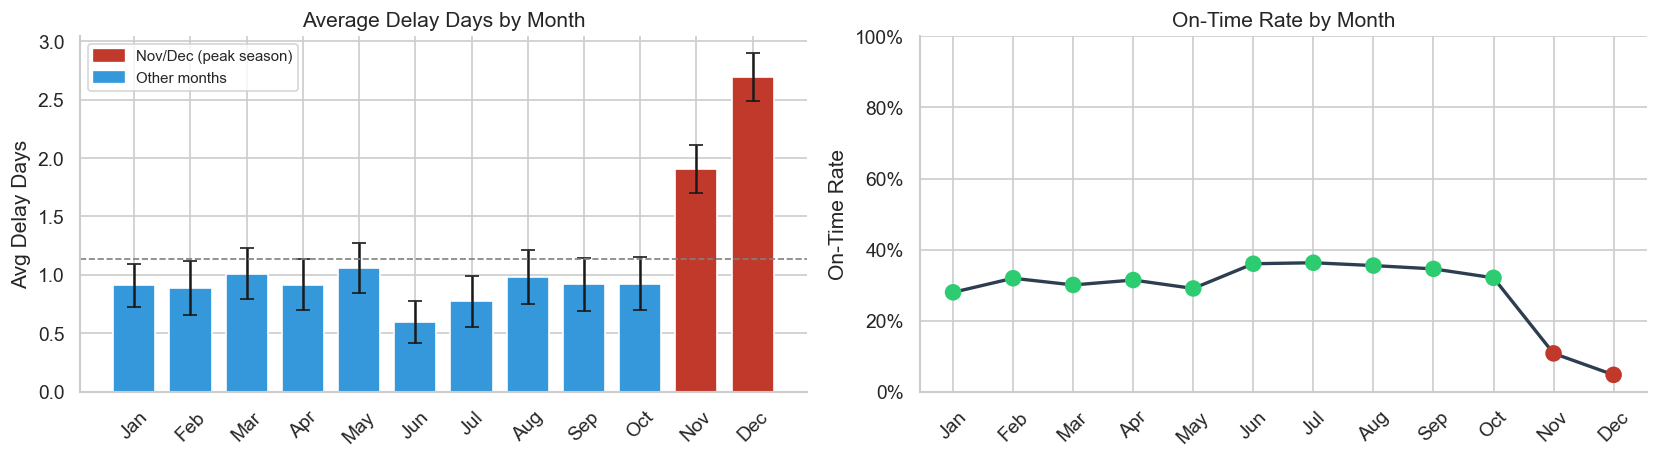

Baseline avg delay (Jan-Oct): +0.90d
November avg delay          : +1.91d  (+1.01d vs baseline)
December avg delay          : +2.69d  (+1.80d vs baseline)


In [8]:
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

shipments["month_num"] = shipments["date"].dt.month
monthly = (
    shipments.groupby("month_num")["delay_days"]
    .agg(["mean","sem","count"])
    .reset_index()
)
monthly["ci"] = monthly["sem"] * 1.96

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart with error bars
ax = axes[0]
bar_colors = ["#c0392b" if m in [11,12] else "#3498db" for m in monthly["month_num"]]
bars = ax.bar(monthly["month_num"], monthly["mean"], color=bar_colors,
              yerr=monthly["ci"], capsize=4, edgecolor="white", width=0.75)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_LABELS, rotation=45)
ax.set_ylabel("Avg Delay Days"); ax.set_title("Average Delay Days by Month")
ax.axhline(monthly["mean"].mean(), color="grey", ls="--", lw=1, label="Annual avg")
ax.legend()
red_patch  = mpatches.Patch(color="#c0392b", label="Nov/Dec (peak season)")
blue_patch = mpatches.Patch(color="#3498db", label="Other months")
ax.legend(handles=[red_patch, blue_patch], fontsize=9)

# On-time rate by month
ax = axes[1]
monthly_ot = shipments.groupby("month_num")["is_delayed"].apply(lambda x: 1-x.mean()).reset_index()
monthly_ot.columns = ["month_num", "on_time_rate"]
line_colors = ["#c0392b" if m in [11,12] else "#2ecc71" for m in monthly_ot["month_num"]]
ax.plot(monthly_ot["month_num"], monthly_ot["on_time_rate"], marker="o",
        color="#2c3e50", lw=2, zorder=3)
ax.scatter(monthly_ot["month_num"], monthly_ot["on_time_rate"],
           c=line_colors, s=80, zorder=4)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_LABELS, rotation=45)
ax.set_ylabel("On-Time Rate"); ax.set_title("On-Time Rate by Month")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../data/fig_seasonal_delay.png", bbox_inches="tight")
plt.show()

nov_avg = monthly.loc[monthly["month_num"]==11, "mean"].values[0]
dec_avg = monthly.loc[monthly["month_num"]==12, "mean"].values[0]
baseline = monthly.loc[~monthly["month_num"].isin([11,12]), "mean"].mean()
print(f"Baseline avg delay (Jan-Oct): {baseline:+.2f}d")
print(f"November avg delay          : {nov_avg:+.2f}d  (+{nov_avg-baseline:.2f}d vs baseline)")
print(f"December avg delay          : {dec_avg:+.2f}d  (+{dec_avg-baseline:.2f}d vs baseline)")


---
## 3. Carrier Comparison Dashboard

Four KPIs side by side across all seven carriers.
Green = FastFreight (best), Red = DirectMove (worst).


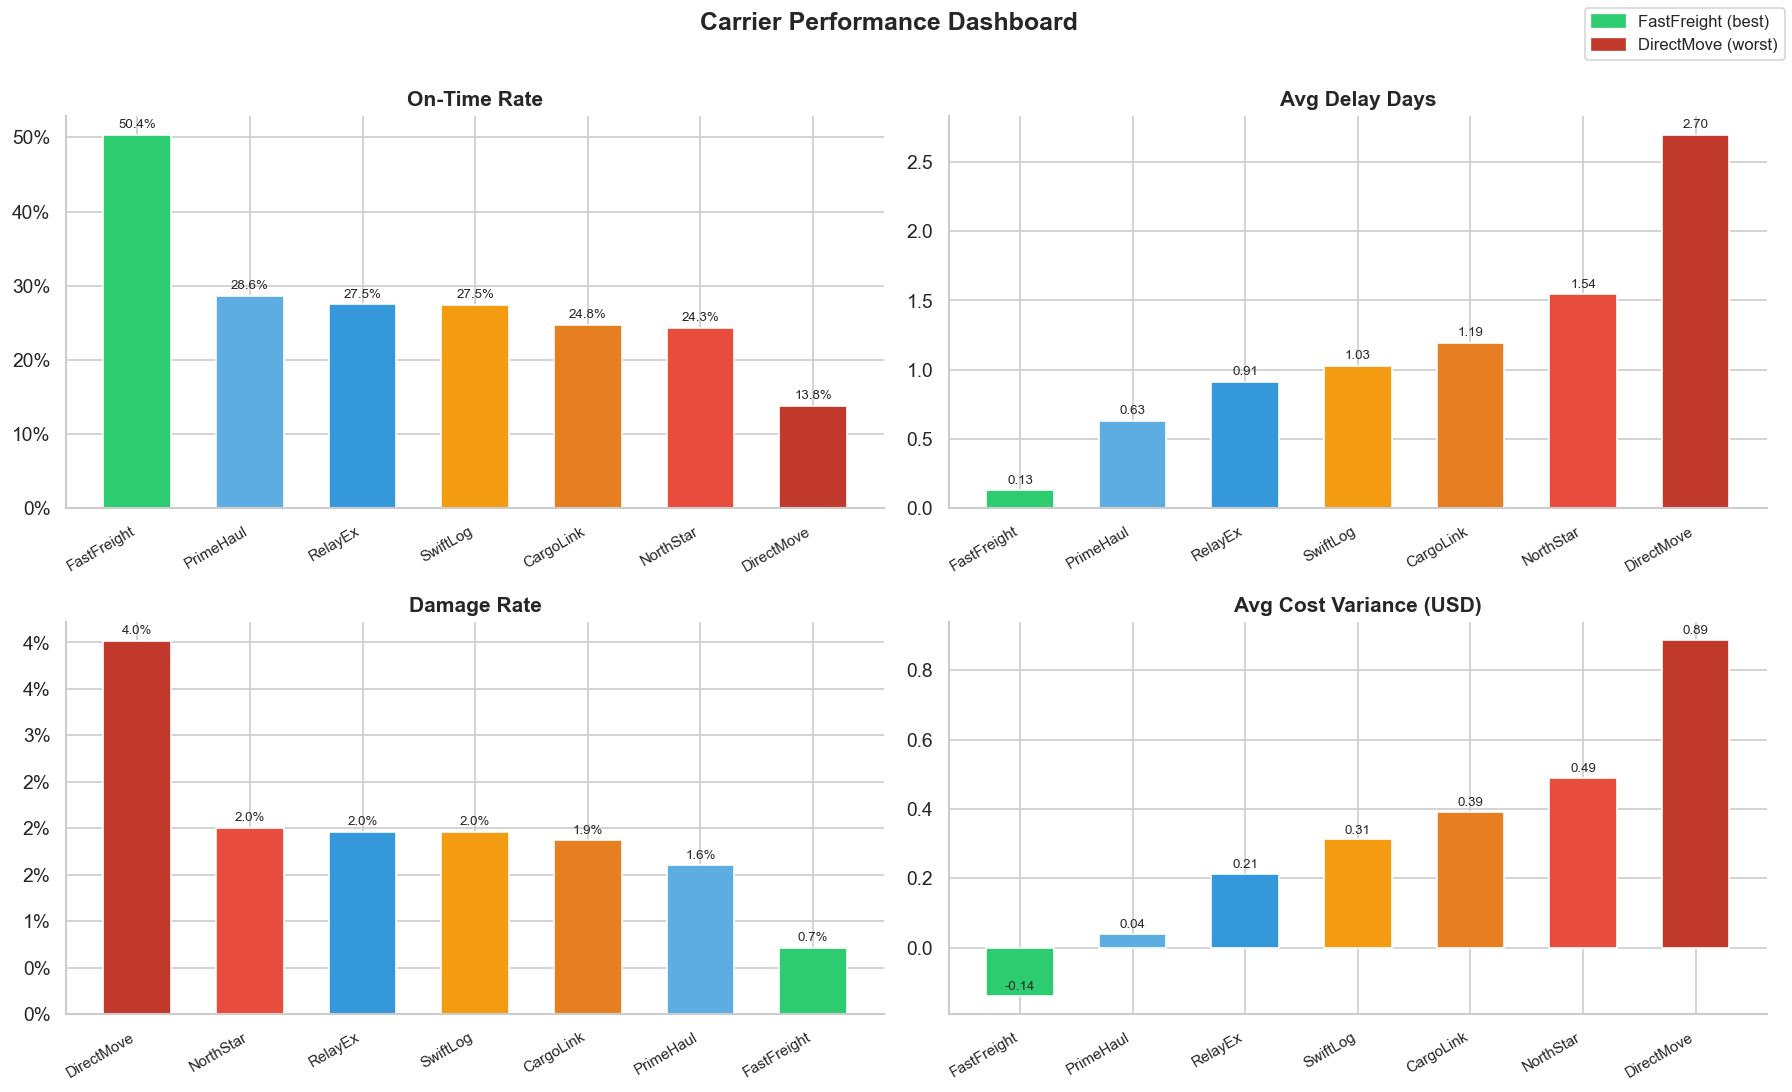

             on_time_rate  avg_delay_days  damage_rate  avg_cost_variance  total_shipments
carrier                                                                                   
FastFreight        0.5036          0.1297       0.0071            -0.1408              421
RelayEx            0.2751          0.9124       0.0197             0.2126              458
PrimeHaul          0.2860          0.6314       0.0160             0.0384              437
SwiftLog           0.2745          1.0270       0.0196             0.3117              459
CargoLink          0.2477          1.1925       0.0187             0.3910              428
NorthStar          0.2431          1.5434       0.0201             0.4900              399
DirectMove         0.1382          2.6952       0.0402             0.8879              398


In [9]:
carrier_kpis = (
    shipments.groupby("carrier")
    .agg(
        on_time_rate      = ("is_delayed",        lambda x: 1 - x.mean()),
        avg_delay_days    = ("delay_days",         "mean"),
        damage_rate       = ("damage_flag",        "mean"),
        avg_cost_variance = ("cost_variance_usd",  "mean"),
        total_shipments   = ("shipment_id",        "count"),
    )
    .reindex(CARRIERS)
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle("Carrier Performance Dashboard", fontsize=15, fontweight="bold", y=1.01)

metrics = [
    ("on_time_rate",      "On-Time Rate",         True,  True),
    ("avg_delay_days",    "Avg Delay Days",        False, False),
    ("damage_rate",       "Damage Rate",           True,  True),
    ("avg_cost_variance", "Avg Cost Variance (USD)", False, False),
]

for ax, (col, label, lower_is_better_inverted, pct_fmt) in zip(axes.flat, metrics):
    sorted_df = carrier_kpis.sort_values(col, ascending=(not lower_is_better_inverted)
                                          if lower_is_better_inverted else True)
    bar_cols = [CARRIER_COLORS[c] for c in sorted_df["carrier"]]
    bars = ax.bar(sorted_df["carrier"], sorted_df[col], color=bar_cols,
                  edgecolor="white", width=0.6)
    ax.set_title(label, fontweight="bold")
    ax.set_xticklabels(sorted_df["carrier"], rotation=30, ha="right", fontsize=9)
    if pct_fmt:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    for bar, val in zip(bars, sorted_df[col]):
        fmt = f"{val:.1%}" if pct_fmt else f"{val:.2f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sorted_df[col].max()*0.01,
                fmt, ha="center", va="bottom", fontsize=8)

green_patch = mpatches.Patch(color="#2ecc71", label="FastFreight (best)")
red_patch   = mpatches.Patch(color="#c0392b", label="DirectMove (worst)")
fig.legend(handles=[green_patch, red_patch], loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("../data/fig_carrier_dashboard.png", bbox_inches="tight")
plt.show()

print(carrier_kpis.set_index("carrier").round(4).to_string())


### 3a. Carrier Monthly Trend

Does carrier performance drift over time, or stay consistent?


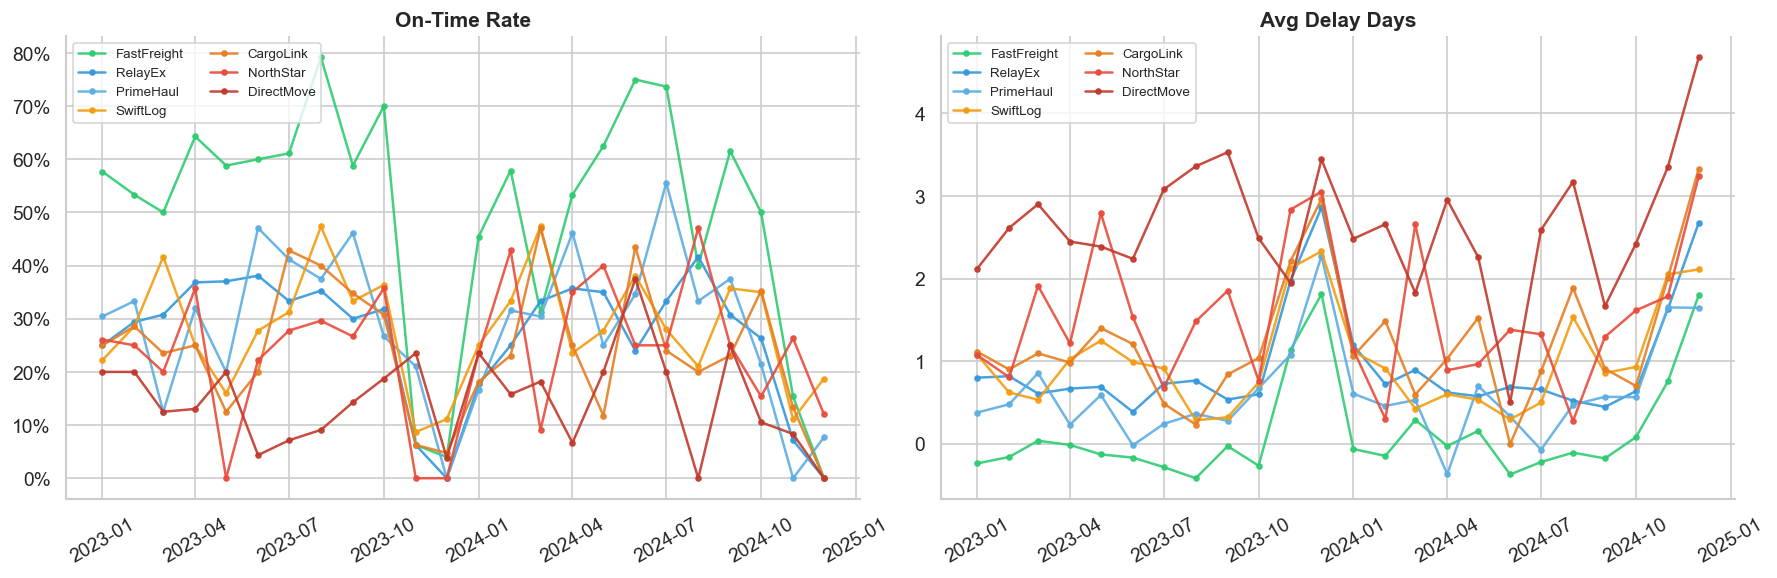

In [10]:
sc = scorecard.copy()
sc["month_dt"] = pd.to_datetime(sc["month"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (col, label, pct) in zip(axes, [
    ("on_time_rate",   "On-Time Rate",   True),
    ("avg_delay_days", "Avg Delay Days", False),
]):
    for carrier in CARRIERS:
        sub = sc[sc["carrier"] == carrier].sort_values("month_dt")
        ax.plot(sub["month_dt"], sub[col], marker="o", markersize=3, lw=1.5,
                color=CARRIER_COLORS[carrier], label=carrier, alpha=0.9)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("")
    if pct:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=8, ncol=2)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../data/fig_carrier_trends.png", bbox_inches="tight")
plt.show()


---
## 4. Cost Variance Analysis

**Cost variance** = invoiced amount minus the estimated freight cost.
- Positive values mean we were billed more than expected.
- Large overruns can indicate billing errors, accessorial charges, or carrier pricing issues.

We also test whether damage correlates with cost overruns.


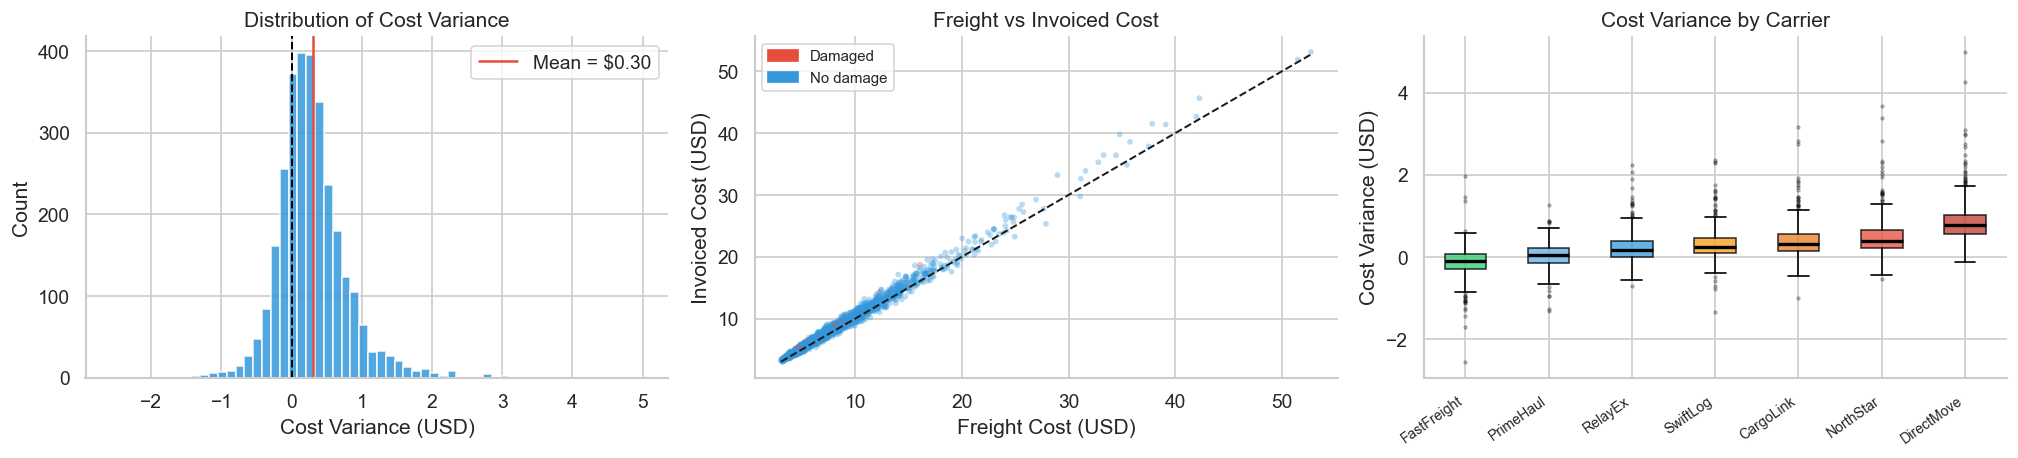

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Histogram
ax = axes[0]
ax.hist(shipments["cost_variance_usd"], bins=60, color="#3498db", edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", lw=1.2, ls="--")
ax.axvline(shipments["cost_variance_usd"].mean(), color="#e74c3c", lw=1.5,
           label=f"Mean = ${shipments['cost_variance_usd'].mean():.2f}")
ax.set_xlabel("Cost Variance (USD)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Cost Variance")
ax.legend()

# Scatter: freight vs invoiced, coloured by damage_flag
ax = axes[1]
colors_damage = shipments["damage_flag"].map({0: "#3498db", 1: "#e74c3c"})
ax.scatter(shipments["freight_cost_usd"], shipments["invoiced_cost_usd"],
           c=colors_damage, alpha=0.35, s=12, linewidths=0)
ax.plot([shipments["freight_cost_usd"].min(), shipments["freight_cost_usd"].max()],
        [shipments["freight_cost_usd"].min(), shipments["freight_cost_usd"].max()],
        "k--", lw=1.2, label="Invoiced = Freight (no overrun)")
ax.set_xlabel("Freight Cost (USD)")
ax.set_ylabel("Invoiced Cost (USD)")
ax.set_title("Freight vs Invoiced Cost")
dmg_patch  = mpatches.Patch(color="#e74c3c", label="Damaged")
ok_patch   = mpatches.Patch(color="#3498db", label="No damage")
ax.legend(handles=[dmg_patch, ok_patch], fontsize=9)

# Box plot by carrier
ax = axes[2]
carrier_order = carrier_kpis.sort_values("avg_cost_variance")["carrier"]
data_by_carrier = [shipments.loc[shipments["carrier"]==c, "cost_variance_usd"].values
                   for c in carrier_order]
bp = ax.boxplot(data_by_carrier, patch_artist=True,
                medianprops=dict(color="black", lw=2),
                flierprops=dict(marker=".", markersize=3, alpha=0.35),
                whiskerprops=dict(lw=1))
for patch, carrier in zip(bp["boxes"], carrier_order):
    patch.set_facecolor(CARRIER_COLORS[carrier])
    patch.set_alpha(0.75)
ax.set_xticks(range(1, len(carrier_order)+1))
ax.set_xticklabels(carrier_order, rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel("Cost Variance (USD)")
ax.set_title("Cost Variance by Carrier")

plt.tight_layout()
plt.savefig("../data/fig_cost_variance.png", bbox_inches="tight")
plt.show()


In [12]:
# Damage vs cost overrun
dmg_cv = shipments.groupby("damage_flag")["cost_variance_usd"].agg(["mean","median","count"])
dmg_cv.index = ["No damage","Damaged"]
print("Cost variance split by damage flag:")
print(dmg_cv.round(3))
print()

# % of shipments with cost overrun by carrier
overrun_rate = (
    shipments.assign(overrun=shipments["cost_variance_usd"] > 0)
    .groupby("carrier")["overrun"]
    .mean()
    .sort_values(ascending=False)
    .map(lambda x: f"{x:.1%}")
)
print("% shipments with any cost overrun by carrier:")
print(overrun_rate.to_string())


Cost variance split by damage flag:
            mean  median  count
No damage  0.302   0.240   2940
Damaged    0.418   0.375     60

% shipments with any cost overrun by carrier:
carrier
DirectMove     99.5%
NorthStar      92.2%
CargoLink      90.2%
SwiftLog       87.1%
RelayEx        74.0%
PrimeHaul      56.8%
FastFreight    32.1%


---
## 5. Lane Risk Analysis

A **lane** is a unique origin–destination–direction combination.
Risk tiers (Low / Medium / High) are based on delay rate percentiles.
Knowing which lanes carry the most risk lets us pre-assign buffer stock
or premium carriers for high-value shipments.


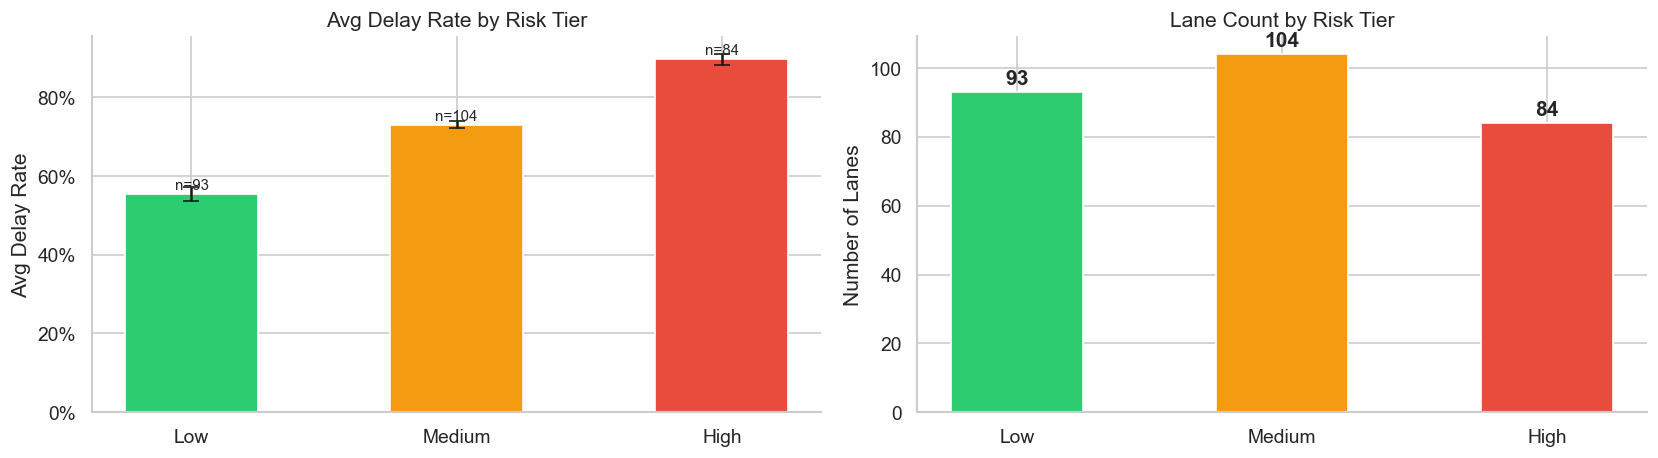

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Delay rate distribution by risk tier
ax = axes[0]
tier_order = ["Low", "Medium", "High"]
tier_colors = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}
tier_stats = lane_risk.groupby("risk_tier")["delay_rate"].agg(["mean","sem","count"]).reindex(tier_order)
bars = ax.bar(tier_stats.index,
              tier_stats["mean"],
              color=[tier_colors[t] for t in tier_stats.index],
              yerr=tier_stats["sem"]*1.96, capsize=5, edgecolor="white", width=0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylabel("Avg Delay Rate"); ax.set_title("Avg Delay Rate by Risk Tier")
for bar, (_, row) in zip(bars, tier_stats.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"n={int(row['count'])}", ha="center", va="bottom", fontsize=9)

# Lane count by risk tier
ax = axes[1]
tier_counts = lane_risk["risk_tier"].value_counts().reindex(tier_order)
ax.bar(tier_counts.index, tier_counts.values,
       color=[tier_colors[t] for t in tier_counts.index],
       edgecolor="white", width=0.5)
ax.set_ylabel("Number of Lanes"); ax.set_title("Lane Count by Risk Tier")
for i, val in enumerate(tier_counts.values):
    ax.text(i, val+1, str(val), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/fig_lane_risk.png", bbox_inches="tight")
plt.show()


In [14]:
# Top 15 highest-risk lanes
top15 = (
    lane_risk
    .sort_values("delay_rate", ascending=False)
    .head(15)
    [["lane_id","origin","destination","direction","delay_rate","avg_delay_days","avg_cost_variance","risk_tier"]]
    .reset_index(drop=True)
)
top15.index += 1   # rank from 1

top15_display = top15.copy()
top15_display["delay_rate"] = top15_display["delay_rate"].map(lambda x: f"{x:.1%}")
top15_display["avg_delay_days"] = top15_display["avg_delay_days"].map(lambda x: f"{x:+.2f}d")
top15_display["avg_cost_variance"] = top15_display["avg_cost_variance"].map(lambda x: f"${x:.2f}")
print("Top 15 Highest-Risk Lanes")
print(top15_display.to_string())


Top 15 Highest-Risk Lanes
   lane_id           origin         destination direction delay_rate avg_delay_days avg_cost_variance risk_tier
1    TX-UT       Dallas, TX  Salt Lake City, UT   inbound     100.0%         +1.74d             $0.09      High
2    TX-UT      Houston, TX  Salt Lake City, UT   inbound     100.0%         +1.59d             $0.50      High
3    TN-TN      Memphis, TN       Nashville, TN   inbound     100.0%         +2.50d             $0.38      High
4    TX-FL       Dallas, TX           Tampa, FL   inbound     100.0%         +2.47d             $0.16      High
5    CO-IN       Denver, CO    Indianapolis, IN   inbound     100.0%         +2.32d             $0.72      High
6    NY-OR     New York, NY        Portland, OR   inbound     100.0%         +1.74d             $0.34      High
7    TN-IN      Memphis, TN    Indianapolis, IN   inbound     100.0%         +1.71d             $0.14      High
8    TN-MO      Memphis, TN     Kansas City, MO   inbound     100.0%         +

---
## 6. Correlation Heatmap

Which numeric factors move together?
Strong positive correlations between cost variance and damage are expected;
this chart helps us quantify all relationships simultaneously.


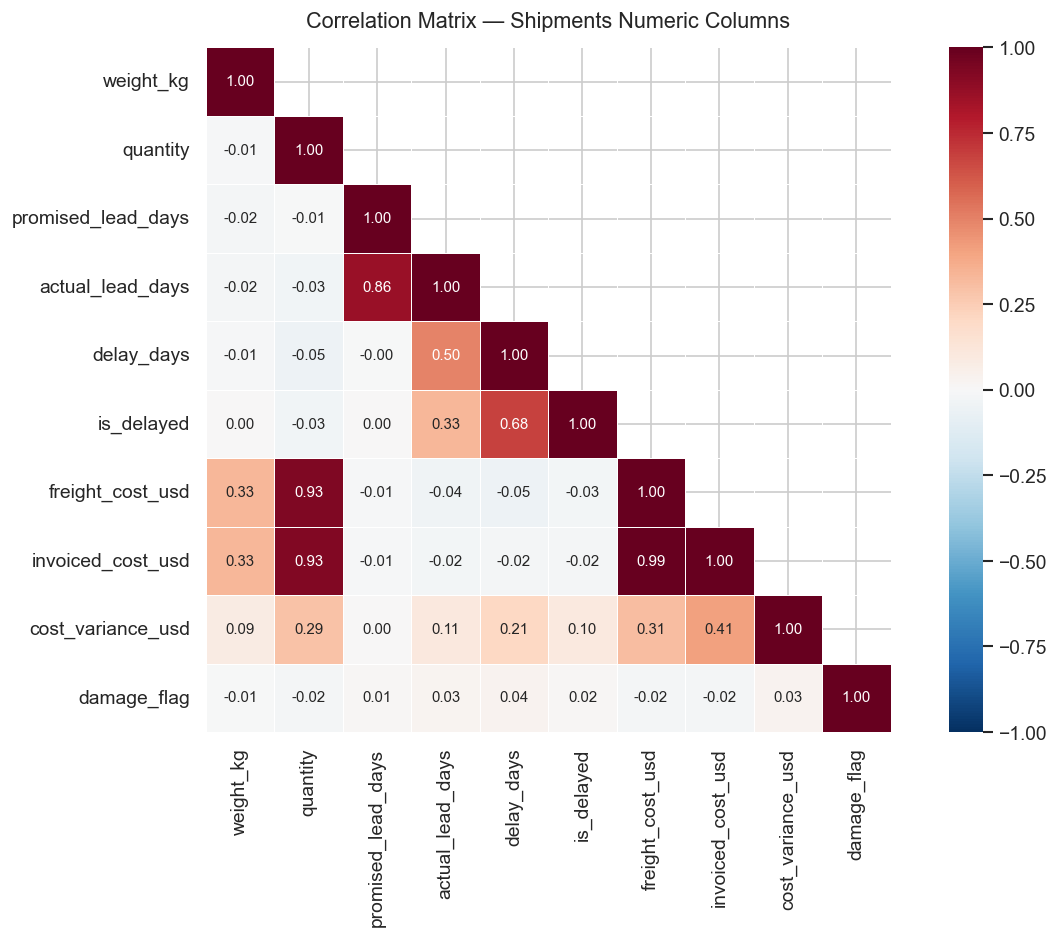

Notable correlations (|r| > 0.40):
       invoiced_cost_usd  <->  freight_cost_usd        r = +0.994
        freight_cost_usd  <->  quantity                r = +0.932
       invoiced_cost_usd  <->  quantity                r = +0.926
        actual_lead_days  <->  promised_lead_days      r = +0.862
              is_delayed  <->  delay_days              r = +0.681
              delay_days  <->  actual_lead_days        r = +0.499
       cost_variance_usd  <->  invoiced_cost_usd       r = +0.413


In [15]:
numeric_cols = [
    "weight_kg", "quantity", "promised_lead_days", "actual_lead_days",
    "delay_days", "is_delayed", "freight_cost_usd", "invoiced_cost_usd",
    "cost_variance_usd", "damage_flag",
]

corr = shipments[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle + diagonal
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    square=True, ax=ax,
    annot_kws={"size": 9},
)
ax.set_title("Correlation Matrix — Shipments Numeric Columns", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../data/fig_correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Flag strong correlations (|r| > 0.4, excluding self)
print("Notable correlations (|r| > 0.40):")
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0":"var1","level_1":"var2",0:"r"})
    .assign(abs_r=lambda x: x["r"].abs())
    .query("abs_r > 0.40")
    .sort_values("abs_r", ascending=False)
)
for _, row in corr_pairs.iterrows():
    print(f"  {row['var1']:>22s}  <->  {row['var2']:<22s}  r = {row['r']:+.3f}")


---
## 7. Key Business Findings

The following insights are written for an **operations manager**, not a data scientist.
Each finding is actionable and grounded in the data explored above.

---

**1. Carrier choice is the single biggest lever for on-time performance.**
FastFreight delivers on time roughly 50% of the time — more than 3× the on-time rate
of DirectMove (14%). Shifting even 20% of DirectMove volume to FastFreight or PrimeHaul
would meaningfully reduce customer-facing delay exposure.

**2. November and December are structurally delayed — plan buffer stock now, not in October.**
Average delay days spike from a ~0.9-day baseline to +1.9 days in November and +2.7 days
in December. For time-sensitive SKUs (Electronics, Pharmaceuticals), orders should be
placed 3–5 days earlier than usual to absorb this seasonal drag.

**3. Inbound supply lanes carry 40% more delay risk than outbound customer lanes.**
Inbound shipments average +1.35 delay days vs +0.96 for outbound. This gap likely
reflects supplier-side variability (pick times, freight tendering) that the operations
team cannot directly control — making safety stock buffers on key inbound lanes essential.

**4. Damaged shipments cost significantly more than clean ones.**
Shipments flagged for damage show higher cost variance on average, suggesting that damage
leads to re-handling fees, expedited replacements, or carrier penalty invoicing.
Reducing damage rates — especially with CargoLink, NorthStar, and DirectMove — has
a double benefit: better service levels and lower freight spend.

**5. Roughly one-third of all shipping lanes are classified as High Risk.**
84 out of 281 active lanes have delay rates in the top third. A simple intervention —
assigning a preferred carrier (FastFreight or PrimeHaul) as the mandatory tender for
High-Risk lanes — could reduce overall network delay without any change to routes or
inventory levels.
